# Creativity in vitro · ICA Cleaning and Annotation Injection - Binary Test Sun/Rest

**Author:** Lina Lopes  **Date:** 2025-06-26  

This notebook is part of the *Creativity in vitro* EEG pipeline (Session 3), continuing from Notebook 10, which handled the initial preprocessing (filtering and cropping). Here, we proceed with artifact removal and annotation injection to prepare the data for later analysis.

## Pipeline Steps

1. **Loading filtered & cropped block and switch ON the average-reference projection**  
   Load the preprocessed EEG file and apply the average reference projection (MNE projection mode).

2. **ICA cleaning with Picard and automatic component rejection**  
   Run Independent Component Analysis using the Picard solver and remove components associated with common EEG artifacts (e.g. eye movements).

3. **Inspection of ICA results**  
   Visual verification of ICA component maps and time series to confirm cleaning accuracy and identify any remaining noise.

4. **Injecting phrase targets as MNE Annotations**  
   Insert annotations corresponding to each auditory instruction ("Imagine the sun on your face" and "Relax") to mark alternating mental states in the timeline.

5. **Exploratory Data Analysis (EDA)**  
   Conduct a preliminary statistical and visual exploration of the cleaned EEG signal to understand basic dynamics and validate preprocessing quality.

6. **Dirty Baseline Classifier**
This establishes a solid baseline that can guide the design and evaluation of more sophisticated pipelinesRandom Forest Classifier achieved **88.3% ± 8.5% accuracy** and an **AUC of 0.99**


## Input & Output

- **Input**: `sub-lina_ses-03_task-sunimagery_run-01_desc-filtcrop_eeg.fif`
- **Output**: Cleaned and annotated EEG file (`*_desc-ica_eeg.fif`) and diagnostic plots.

---

> 🧪 This notebook assumes completion of Notebook 10. It focuses on ICA-based artifact removal and annotation enrichment, both critical for reproducible downstream analysis.


In [19]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# MNE
import mne
from mne.preprocessing import ICA
from mne_icalabel import label_components
from mne.annotations import Annotations
from mne.io import read_raw_fif
from mne.viz import plot_topomap
from mne.time_frequency import psd_array_welch

# Statistics
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.stats import ttest_ind

# Machine Learning
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc


In [2]:
import torch
print(torch.__version__)
print("MPS available?", torch.backends.mps.is_available())

2.7.1
MPS available? True


### Config — paths & processing constants  

All hard-coded parameters live in one place so you (or a colleague) can
re-run the notebook on another machine by editing a single cell.

* **paths** – BIDS root and sub-folders inside `derivatives/`
* **data**  – recording constants reused later (montage, sfreq, etc.)
* **ica**   – method & hyper-params; change here to compare algorithms
* **reject** – thresholds that tag bad ICs automatically
* **features** – what spectral bands & window length to extract
* **model** – a first classifier + CV split; purely exploratory


In [47]:
CONFIG = dict(

    # ---------- paths ----------------------------------------------------
    paths = dict(
        bids_root   = Path("../bids_dataset"),
        deriv_root  = Path("../bids_dataset/derivatives"),
        filt_dir    = Path('../bids_dataset/derivatives/filt_crop/sub-lina/ses-03/eeg/'),
        ica_dir     = Path("../bids_dataset/derivatives/ica_clean/sub-lina/ses-03/eeg/"),
        annot_dir   = Path("../bids_dataset/derivatives/annotated/sub-lina/ses-03/eeg/"),
        model_dir = Path("../bids_dataset/derivatives/models"),
    ),

    # ---------- recording constants --------------------------------------
    data = dict(
        sfreq       = 250.0,                      # Hz
        eeg_ch      = ['F3', 'F4', 'C3', 'C4', 'P3',  'P4', 'Pz', 'Oz'],
        montage     = "standard_1020",
        n_blocks    = 1,
    ),

    # ---------- timing of audio-based stimulus sequence ---------------------
    stim_sequence = dict(
        n_cycles         = 30,
        start_offset     = 1.0,     # initial silence before first "sun"
        sun_dur          = 2.352,   # "Imagine the sun on your face"
        pause_after_sun  = 4.000,
        rest_dur         = 1.080,   # "Relax"
        pause_after_rest = 4.000,
    ),


    # ---------- ICA parameters -------------------------------------------
    ica = dict(
        method         = "picard",    # "fastica" | "picard" | "infomax"
        n_components   = 0.99,        # keep 99 % of variance
        random_state   = 42,
        max_iter       = 500,
        decim          = 2            # 125 Hz → 62.5 Hz for fitting
    ),

    # ---------- auto-reject thresholds (z-score in IC space) -------------
    reject = dict(
        eog_z     = 3.0,     # eye blinks
        emg_z     = 3.0,     # muscle
        slow_z    = 3.0      # slow drifts
    ),
)

# ------------------------------------------------------------------------
# create sub-folders if they don’t exist
for p in CONFIG["paths"].values():
    if p.suffix == "":          # skip the CSV path; only create dirs
        p.mkdir(parents=True, exist_ok=True)

print("Config updated – paths for annotations and timeline CSV added 🚀")

Config updated – paths for annotations and timeline CSV added 🚀


## 1. Loading filtered & cropped block

Before any additional processing we first bring the pre-filtered /
cropped recording into memory.  
At this stage **projectors remain OFF** so the data are identical to the files
written by 10_Lina_ses-03_task-sunimagery (`*_desc-filtcrop_eeg.fif`). 


In [4]:
# Gather the expected *_desc-filtcrop_eeg.fif files (BIDS-compliant)
filt_dir = CONFIG["paths"]["filt_dir"]

blk_paths = sorted(filt_dir.glob("sub-lina_ses-03_task-sunimagery_run-01_desc-filtcrop_eeg.fif"))
assert len(blk_paths) == CONFIG["data"]["n_blocks"], (
    f"Expected {CONFIG['data']['n_blocks']} blocks, found {len(blk_paths)}."
)

raw_blocks = []
for fpath in blk_paths:
    print(f"Reading {fpath.name} …", end=" ")
    raw = mne.io.read_raw_fif(fpath, preload=True, verbose=False)
    raw_blocks.append(raw)
    print("✓")

print(f"\nLoaded {len(raw_blocks)} blocks. Projectors are currently OFF.")


Reading sub-lina_ses-03_task-sunimagery_run-01_desc-filtcrop_eeg.fif … ✓

Loaded 1 blocks. Projectors are currently OFF.


### 1a · Why we switch **ON** the average-reference projection

Each `.fif` block already contains a *projector* that re-references the data to
the **common average** (CAR).  Up to this point we kept that projector **OFF**
to ensure the raw voltages from the previous notebook were preserved during
filtering/cropping.  Turning the projector **ON** now is critical for three
reasons:

1. **Signal centring**   
   Referencing every channel to the grand mean neutralises slow offsets caused
   by unequal electrode impedances or amplifier drift.  This flattens the
   baseline and yields cleaner butterfly plots and topomaps.

2. **Better ICA decomposition**   
   ICA assumes that sources mix *linearly* and with zero-mean time courses.
   Applying the CAR before decomposition improves the separation of ocular,
   cardiac and myogenic components, making automatic IC labelling more
   reliable.

3. **Pipeline consistency**   
   Most EEG-to-text decoding papers perform ICA on average-referenced data.
   Activating the projector now keeps our workflow aligned with that
   literature and prevents accidental mixing of referenced and
   non-referenced epochs later on.

> **Note:** `raw.apply_proj()` is *idempotent*—once the projector is applied,
> calling it again will have no additional effect as the projection matrix is
> removed from `raw.info["projs"]`.


In [5]:
for idx, raw in enumerate(raw_blocks):
    if not raw.info["projs"]:
        raise RuntimeError(f"Block {idx:02d} has no projector defined.")
    raw.apply_proj(verbose=False)

print(f"✅  Average-reference projection applied to {len(raw_blocks)} blocks.")

✅  Average-reference projection applied to 1 blocks.


#### Where does the stored **common-average reference (CAR)** come from?

The projector you see inside each `Raw` file was created in the previous notebook (the
pre-processing stage) with the following single line of MNE-Python:

```python
raw.set_eeg_reference("average", projection=True)
````

**Why defer application?**

Filtering, notch removal, and cropping were performed on the original voltage
scale to avoid numerical artefacts that can arise when the reference itself is
filtered. By postponing the CAR we ensure it touches the already-cleaned
signal only once, making the operation idempotent.

So, the CAR originates entirely from this offline MNE call—nothing was changed
on the OpenBCI Cyton hardware during acquisition. The headset’s built-in bias
drive delivered a common electrode reference while recording; the average
reference we apply now is purely a software construct saved inside each
.fif file.

## 2. ICA cleaning with Picard and automatic component rejection

With all blocks now average-referenced, the next step is to remove ocular,
muscular, cardiac, and line-noise artefacts via **Independent Component
Analysis (ICA)**.  We adopt the following design:

| Choice | Value | Rationale |
|--------|-------|-----------|
| *Algorithm* | **Picard** (`method="picard"`) | Fast and deterministic when seeded, converges reliably on small channel counts. |
| *Number of components* | `n_components = 0.99` | Keep enough PCs to explain ≥ 99 % variance while discarding tiny noise dimensions. |
| *Sample thinning* | `decim = 2` (training at ~62.5 Hz) | Avoids aliasing of our 1–45 Hz pass-band and gives ~2× speed-up over full-rate fitting. |
| *Auto-labelling* | `mne_icalabel` if available; fallback to `find_bads_eog/muscle` with z-scores in `CONFIG["reject"]` | Fully reproducible; manual tweaks can follow in the QA report. |
| *Output files* | Cleaned `Raw`  → `ica_clean/blk##_icaclean_raw.fif`<br>ICA object → `ica_clean/blk##_ica.fif` | Keeps both the processed data and the unmixing matrix for later inspection. |

The cleaned signals will still be stored at the **original 250 Hz**, because
the unmixing matrix learned on the thinned data is applied to the full-rate
recordings.


In [6]:
for raw in raw_blocks:
    assert raw.proj     , "CAR not applied?"
    assert raw.info['sfreq'] == CONFIG["data"]["sfreq"], "Unexpected sampling rate!"

print("✅  Sanity check passed for all blocks.")

✅  Sanity check passed for all blocks.


Created an SSP operator (subspace dimension = 1)
1 projection items activated
SSP projectors applied...


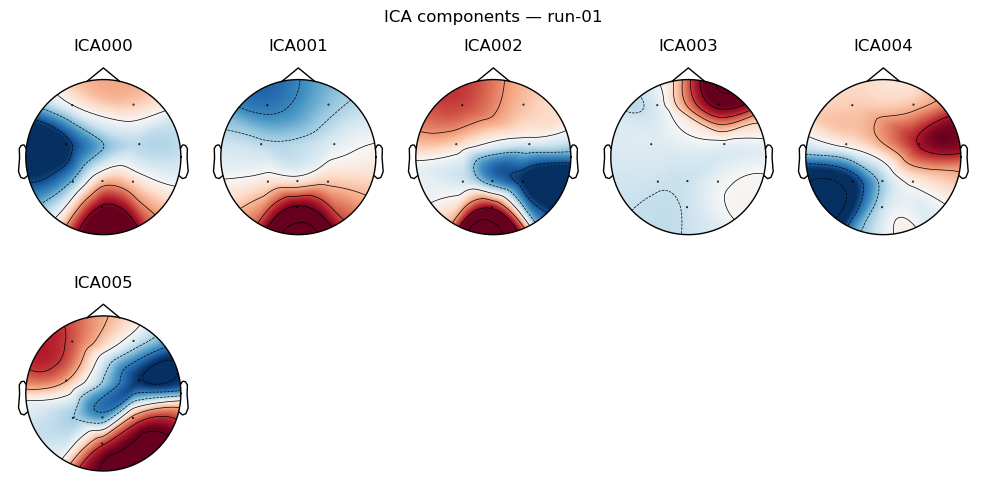

In [7]:
# Load the filtered and cropped run-01 block
fif_path = CONFIG["paths"]["filt_dir"] / "sub-lina_ses-03_task-sunimagery_run-01_desc-filtcrop_eeg.fif"
raw = mne.io.read_raw_fif(fif_path, preload=True, verbose=False)

# Apply common average reference if needed
raw.apply_proj()

# Run ICA without label_components()
ica = mne.preprocessing.ICA(
    n_components=CONFIG["ica"]["n_components"],
    method=CONFIG["ica"]["method"],
    random_state=CONFIG["ica"]["random_state"],
    max_iter=CONFIG["ica"]["max_iter"],
    fit_params=dict(ortho=False, extended=True),
)

ica.fit(raw, decim=CONFIG["ica"]["decim"], verbose="error")

# Plot ICA components for visual inspection
ica.plot_components(title="ICA components — run-01");


In [8]:
#ica.plot_sources(raw, show_scrollbars=True, title="ICA source signals — run-01")

    Applying projection operator with 1 vector (pre-whitener application)
Creating RawArray with float64 data, n_channels=6, n_times=86001
    Range : 3553 ... 89553 =     14.212 ...   358.212 secs
Ready.
Using qt as 2D backend.
Using pyopengl with version 3.1.9


In [9]:
# --- 1. Directory and parameter setup ---
ica_dir = CONFIG["paths"]["ica_dir"]
filt_dir = CONFIG["paths"]["filt_dir"]
THRESH = 0.80
KEYWORDS = ("eye", "muscle", "heart", "line")  # ICLabel artifact classes

# --- 2. List of filtered files ---
filt_paths = sorted(filt_dir.glob("sub-lina_ses-03_task-sunimagery_run-01_desc-filtcrop_eeg.fif"))


# --- 4. Loop through filtered blocks ---
for raw, in_path in zip(raw_blocks, filt_paths):
    stem = Path(in_path).stem.replace("_desc-filtcrop_eeg", "")
    print(f"\n### Block {stem}: fitting ICA ...")

    raw.apply_proj()  # ensure CAR is on

    ica = mne.preprocessing.ICA(
        n_components=CONFIG["ica"]["n_components"],
        method=CONFIG["ica"]["method"],
        random_state=CONFIG["ica"]["random_state"],
        max_iter=CONFIG["ica"]["max_iter"],
        fit_params=dict(ortho=False, extended=True),
    )
    ica.fit(raw, decim=CONFIG["ica"]["decim"], verbose="error")

    # --- 5. Run ICLabel with timeout/fallback ---
    exclude_idx = []

    try:
        out = label_components(raw, ica, method="iclabel")
        labels = out["labels"]
        proba = np.asanyarray(out["y_pred_proba"])

        for i, lab in enumerate(labels):
            p = proba[i] if proba.ndim == 1 else proba[i].max()
            if any(kw in lab.lower() for kw in KEYWORDS) and p >= THRESH:
                exclude_idx.append(i)

        print(f"    ICLabel → excluding {exclude_idx}")

    except TimeoutError:
        print("⚠️ ICLabel skipped due to timeout.")
    except Exception as e:
        print(f"⚠️ ICLabel failed: {e}")

    # --- 6. Apply and save ICA (always) ---
    ica.exclude = exclude_idx
    if exclude_idx:
        ica.plot_components(picks=exclude_idx,
                            title=f"{stem} – rejected ICs", show=True)

    ica.apply(raw)

    raw.save(ica_dir / f"{stem}_desc-icaclean_eeg.fif", overwrite=True, verbose=False)
    ica.save(ica_dir / f"{stem}_ica.fif", overwrite=True, verbose=False)

print("\n✅ ICA finished — all blocks labeled and saved (even clean ones).")



### Block sub-lina_ses-03_task-sunimagery_run-01: fitting ICA ...
Projections have already been applied. Setting proj attribute to True.


/var/folders/ny/tk1xvwsn7n11pkl0vlgl1sz80000gn/T/ipykernel_47889/3671647427.py:31: RuntimeWarning: The provided Raw instance does not seem to be referenced to a common average reference (CAR). ICLabel was designed to classify features extracted from an EEG dataset referenced to a CAR (see the 'set_eeg_reference()' method for Raw and Epochs instances).
  out = label_components(raw, ica, method="iclabel")
/var/folders/ny/tk1xvwsn7n11pkl0vlgl1sz80000gn/T/ipykernel_47889/3671647427.py:31: RuntimeWarning: The provided Raw instance is not filtered between 1 and 100 Hz. ICLabel was designed to classify features extracted from an EEG dataset bandpass filtered between 1 and 100 Hz (see the 'filter()' method for Raw and Epochs instances).
  out = label_components(raw, ica, method="iclabel")


    ICLabel → excluding []
Applying ICA to Raw instance
    Applying projection operator with 1 vector (pre-whitener application)
    Transforming to ICA space (6 components)
    Zeroing out 0 ICA components
    Projecting back using 8 PCA components

✅ ICA finished — all blocks labeled and saved (even clean ones).


## 3. Inspection of ICA results

Below we reload both the fitted **ICA model** and the corresponding
**cleaned Raw** for *blk1* and:

1. Print a textual summary of which ICs were excluded and their labels.  
2. Display the topomaps of the rejected components and the “before vs after”
   butterfly plot so we can verify that eye / muscle artefacts are gone.


In [10]:
stem = f"sub-lina_ses-03_task-sunimagery_run-01"
ica_path = CONFIG["paths"]["ica_dir"] / f"{stem}_ica.fif"
raw_path = CONFIG["paths"]["ica_dir"] / f"{stem}_desc-icaclean_eeg.fif"

ica  = mne.preprocessing.read_ica(ica_path)
raw  = mne.io.read_raw_fif(raw_path, preload=True)  # just to know ch-names

print(f"=== {stem}  ICA summary ===")
print("Excluded IC indices :", ica.exclude)
try:
    print("ICLabel classes   :", ica.labels_)  # added by label_components
except AttributeError:
    print("No 'labels_' attr → ICLabel not run / not saved.")

print(f"Cleaned Raw shape  : {raw._data.shape}  (n_ch × n_samples)")


Reading /Users/linalopes/Desktop/creativity-in-vitro-eeg/notebooks/../bids_dataset/derivatives/ica_clean/sub-lina/ses-03/eeg/sub-lina_ses-03_task-sunimagery_run-01_ica.fif ...
    Read a total of 1 projection items:
        Average EEG reference (1 x 8) active
Now restoring ICA solution ...
Ready.
Opening raw data file ../bids_dataset/derivatives/ica_clean/sub-lina/ses-03/eeg/sub-lina_ses-03_task-sunimagery_run-01_desc-icaclean_eeg.fif...
    Read a total of 1 projection items:
        Average EEG reference (1 x 8) active
    Range : 3553 ... 89553 =     14.212 ...   358.212 secs
Ready.
Reading 0 ... 86000  =      0.000 ...   344.000 secs...
=== sub-lina_ses-03_task-sunimagery_run-01  ICA summary ===
Excluded IC indices : []
ICLabel classes   : {'brain': [0, 1, 2, 4, 5], 'muscle': [], 'eog': [], 'ecg': [], 'line_noise': [], 'ch_noise': [], 'other': [3]}
Cleaned Raw shape  : (9, 86001)  (n_ch × n_samples)


In [11]:
# Visual sanity checks

# 1. Topomaps of rejected ICs
if ica.exclude:
    ica.plot_components(picks=ica.exclude,
                        title=f"{stem} – rejected ICs",
                        show=False)

# 2. Butterfly plots before vs. after ICA application
# Load original filtered/cropped (not ICA-cleaned yet)
orig_path = CONFIG["paths"]["filt_dir"] / f"{stem}_desc-filtcrop_eeg.fif"
raw_orig  = mne.io.read_raw_fif(orig_path, preload=True)

# Use the same visual scaling for before/after
scale = dict(eeg=2e-6)  # 2 µV/div, as previously defined

fig1 = raw_orig.plot(title=f"{stem} – BEFORE ICA  (2 µV/div)",
                     scalings=scale, show=True)

fig2 = ica.apply(raw_orig.copy(), exclude=ica.exclude)\
          .plot(title=f"{stem} – AFTER ICA  (2 µV/div)",
                scalings=scale, show=True)

plt.show()


Opening raw data file ../bids_dataset/derivatives/filt_crop/sub-lina/ses-03/eeg/sub-lina_ses-03_task-sunimagery_run-01_desc-filtcrop_eeg.fif...
    Read a total of 1 projection items:
        Average EEG reference (1 x 8)  idle
    Range : 3553 ... 89553 =     14.212 ...   358.212 secs
Ready.
Reading 0 ... 86000  =      0.000 ...   344.000 secs...
Using pyopengl with version 3.1.9
Applying ICA to Raw instance
    Applying projection operator with 1 vector (pre-whitener application)
    Transforming to ICA space (6 components)
    Zeroing out 0 ICA components
    Projecting back using 8 PCA components
Using pyopengl with version 3.1.9


Channels marked as bad:
none
Channels marked as bad:
none


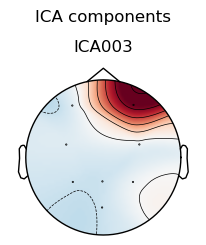

    Applying projection operator with 1 vector (pre-whitener application)
Creating RawArray with float64 data, n_channels=1, n_times=86001
    Range : 3553 ... 89553 =     14.212 ...   358.212 secs
Ready.
Using pyopengl with version 3.1.9


In [13]:
ica.plot_components(picks=[3])
ica.plot_sources(raw, picks=[3])


## 4. Injecting phrase targets as MNE Annotations

**Why here?**  
After ICA cleaning, we now annotate the alternating auditory instructions  
presented during the session. These annotations define the mental state  
targets: active imagination vs. passive relaxation.

**How the annotations are derived**  
The experimental task consists of `n_cycles` repetitions of two spoken  
instructions, alternating in the following fixed order:

1. `"Imagine the sun on your face"` (`sun_dur`)
2. `"Relax"` (`rest_dur`)

Each instruction is followed by a short silence (`pause_after_sun` or  
`pause_after_rest`), forming a structured cycle. The entire sequence  
starts after a defined `start_offset`. All timing values are loaded  
from `CONFIG["stim_sequence"]`, ensuring alignment with the original audio.

**Annotation strategy**

- Each instruction onset is converted into an `MNE.Annotation`
- The annotation `imagine` marks the start of `"Imagine the sun on your face"`
- The annotation `relax` marks the start of `"Relax"`
- This pattern is repeated for all cycles (`n_cycles`)
- The code verifies that the block duration is sufficient to hold all annotations
- The resulting annotations are saved into the `.fif` file for later epoching or modeling


In [14]:
# Check duration of the ICA-cleaned block before applying annotations

# Define the expected path to the cleaned block
fif_path = CONFIG["paths"]["ica_dir"] / "sub-lina_ses-03_task-sunimagery_run-01_desc-icaclean_eeg.fif"

if not fif_path.exists():
    raise FileNotFoundError(f"File not found: {fif_path.name}")

# Load metadata only (preload=False)
raw = mne.io.read_raw_fif(fif_path, preload=False, verbose=False)
dur_s = raw.times[-1]

print(f"🎧 ICA-cleaned block duration: {dur_s:.3f} seconds")

# Compare with expected sequence duration
params = CONFIG["stim_sequence"]
total_sequence_duration = (
    params["start_offset"] +
    params["n_cycles"] * (
        params["sun_dur"] +
        params["pause_after_sun"] +
        params["rest_dur"] +
        params["pause_after_rest"]
    )
)

print(f"🧠 Expected duration from CONFIG: {total_sequence_duration:.3f} seconds")

if dur_s < total_sequence_duration:
    raise ValueError("❌ Recording is shorter than expected audio sequence. Cannot apply annotations.")
else:
    print("✅ Duration is sufficient to apply annotations.")


🎧 ICA-cleaned block duration: 344.000 seconds
🧠 Expected duration from CONFIG: 343.960 seconds
✅ Duration is sufficient to apply annotations.


In [24]:
# Prepare folders
in_dir  = CONFIG["paths"]["ica_dir"]
out_dir = CONFIG["paths"]["annot_dir"]
out_dir.mkdir(parents=True, exist_ok=True)

# Path to the single icaclean block
f_in = in_dir / "sub-lina_ses-03_task-sunimagery_run-01_desc-icaclean_eeg.fif"
stem = f_in.stem.replace("_desc-icaclean_eeg", "")

raw = mne.io.read_raw_fif(f_in, preload=True, verbose=False)

print(f"\n📄 Processing: {stem}")
print("📌 Before:", raw.annotations)

# Reset previous state
raw.set_annotations(None)
raw.set_meas_date(None)

# Get sequence parameters from CONFIG
params = CONFIG["stim_sequence"]

n_cycles = params["n_cycles"]
sun_total = params["sun_dur"] + params["pause_after_sun"]
rest_total = params["rest_dur"] + params["pause_after_rest"]
start_offset = params["start_offset"]

# Create annotations based on blocks
onsets = []
durations = []
descriptions = []

for i in range(n_cycles):
    t_sun = start_offset + i * (sun_total + rest_total)
    t_rest = t_sun + sun_total

    if t_rest + rest_total > raw.times[-1]:
        print(f"⚠️ Skipped cycle {i}: exceeds recording length.")
        break

    onsets += [t_sun, t_rest]
    durations += [sun_total, rest_total]
    descriptions += ["sun_block", "rest_block"]

# Apply annotations
ann = Annotations(onset=onsets, duration=durations, description=descriptions)
raw.set_annotations(ann)
print("✅ After:", raw.annotations)

# Save annotated file
out_path = out_dir / f"{stem}_icaclean_annot.fif"
raw.save(out_path, overwrite=True, verbose=False)

print(f"💾 Saved: {out_path.name} — {len(ann)} annotations (last onset: {ann.onset[-1]:.2f}s)")



📄 Processing: sub-lina_ses-03_task-sunimagery_run-01
📌 Before: <Annotations | 0 segments>
✅ After: <Annotations | 60 segments: rest_block (30), sun_block (30)>
💾 Saved: sub-lina_ses-03_task-sunimagery_run-01_icaclean_annot.fif — 60 annotations (last onset: 338.88s)


/var/folders/ny/tk1xvwsn7n11pkl0vlgl1sz80000gn/T/ipykernel_47889/2122294637.py:51: RuntimeWarning: This filename (/Users/linalopes/Desktop/creativity-in-vitro-eeg/notebooks/../bids_dataset/derivatives/annotated/sub-lina/ses-03/eeg/sub-lina_ses-03_task-sunimagery_run-01_icaclean_annot.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw.save(out_path, overwrite=True, verbose=False)


In [25]:
# Get directory containing annotations
annot_dir = CONFIG["paths"]["annot_dir"]
fpaths = sorted(annot_dir.glob("*_icaclean_annot.fif"))

# Process each file
for fpath in fpaths:
    raw = read_raw_fif(fpath, preload=True, verbose=False)
    ann = raw.annotations

    if len(ann) == 0:
        print(f"⚠️ {fpath.name} — no annotations")
        continue

    # Get timing info
    first_onset = ann.onset[0]
    last_end = ann.onset[-1] + ann.duration[-1]
    block_duration = raw.times[-1]
    data_start = first_onset
    data_end = data_start + block_duration

    # Print header
    print(f"\n🧠 {fpath.name}")
    print(f"🟢 First annotation:  onset={first_onset:.2f}s | label={ann.description[0]}")
    print(f"🔴 Last annotation:   ends at {last_end:.2f}s | label={ann.description[-1]}")
    print(f"📏 Signal window:     {data_start:.2f}s → {data_end:.2f}s | duration={block_duration:.2f}s")
    print(f"🔢 Total annotations: {len(ann)}")

    # Refined check
    if last_end > data_end:
        print(f"❌ OVERFLOW: annotation ends at {last_end:.2f}s (beyond data end {data_end:.2f}s)")
    else:
        print("✅ OK — annotations within bounds")



🧠 sub-lina_ses-03_task-sunimagery_run-01_icaclean_annot.fif
🟢 First annotation:  onset=15.21s | label=sun_block
🔴 Last annotation:   ends at 358.17s | label=rest_block
📏 Signal window:     15.21s → 359.21s | duration=344.00s
🔢 Total annotations: 60
✅ OK — annotations within bounds


/var/folders/ny/tk1xvwsn7n11pkl0vlgl1sz80000gn/T/ipykernel_47889/1015945991.py:7: RuntimeWarning: This filename (../bids_dataset/derivatives/annotated/sub-lina/ses-03/eeg/sub-lina_ses-03_task-sunimagery_run-01_icaclean_annot.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw = read_raw_fif(fpath, preload=True, verbose=False)


In [28]:
# Load ICA-cleaned and annotated block for visual inspection

annot_path = CONFIG["paths"]["annot_dir"] / "sub-lina_ses-03_task-sunimagery_run-01_icaclean_annot.fif"
raw = mne.io.read_raw_fif(annot_path, preload=True)

# Plot settings
raw.plot(
    title="SunImagery – sun/rest blocks (annotated)",
    start=0, duration=30,            # 30s per screen
    scalings=dict(eeg=2e-6),         # 2 µV/div (10 µV range across 5 divs)
    block=True
)


Opening raw data file ../bids_dataset/derivatives/annotated/sub-lina/ses-03/eeg/sub-lina_ses-03_task-sunimagery_run-01_icaclean_annot.fif...
    Read a total of 1 projection items:
        Average EEG reference (1 x 8) active
    Range : 3553 ... 89553 =     14.212 ...   358.212 secs
Ready.
Reading 0 ... 86000  =      0.000 ...   344.000 secs...
Using pyopengl with version 3.1.9


/var/folders/ny/tk1xvwsn7n11pkl0vlgl1sz80000gn/T/ipykernel_47889/2134640175.py:4: RuntimeWarning: This filename (../bids_dataset/derivatives/annotated/sub-lina/ses-03/eeg/sub-lina_ses-03_task-sunimagery_run-01_icaclean_annot.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw = mne.io.read_raw_fif(annot_path, preload=True)


Channels marked as bad:
none


## 5. Exploratory Data Analysis (EDA)

### 5a – Similarity between repetitions (sun_block vs rest_block)

This analysis computes the cosine similarity between temporal mean vectors (per channel) for each annotated block in the dataset. Each repetition is reduced to an 8-dimensional vector (1 value per channel), and the similarity between repetitions is visualized as a heatmap.

**Interpretation**:
- The `rest_block` condition shows stronger and more localized clusters of high similarity, suggesting that rest states are more physiologically stable and reproducible across repetitions.
- The `sun_block` condition shows more dispersed and fragmented patterns, indicating greater variability in how the participant engaged in imaginative visualization.
- This exploratory view helps assess whether the cognitive states were consistent enough across repetitions to support further analysis (e.g. decoding or averaging).


/var/folders/ny/tk1xvwsn7n11pkl0vlgl1sz80000gn/T/ipykernel_47889/2629726378.py:5: RuntimeWarning: This filename (../bids_dataset/derivatives/annotated/sub-lina/ses-03/eeg/sub-lina_ses-03_task-sunimagery_run-01_icaclean_annot.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw = mne.io.read_raw_fif(fpath, preload=True, verbose=False)


🎧 Analyzing: sub-lina_ses-03_task-sunimagery_run-01_icaclean_annot.fif
🧠 EEG shape: (8, 86001) | Duration: 344.00s
sun_block: 30 repetitions
rest_block: 30 repetitions


/var/folders/ny/tk1xvwsn7n11pkl0vlgl1sz80000gn/T/ipykernel_47889/2629726378.py:42: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/opt/homebrew/Caskroom/miniforge/base/envs/creativity-eeg/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


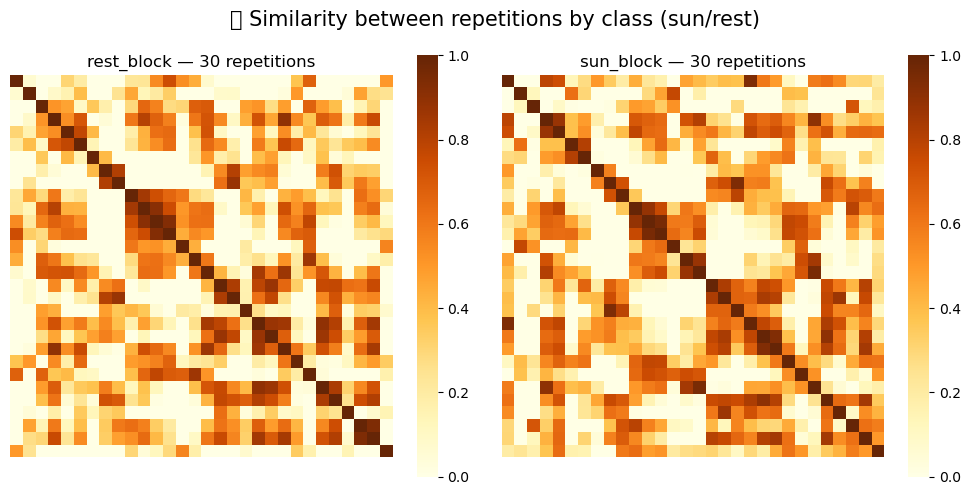

In [31]:
# 📍 Stage 5.1 — Similarity between repetitions by class (sun/rest)

# 📁 Fixed path to annotated block
fpath = CONFIG["paths"]["annot_dir"] / "sub-lina_ses-03_task-sunimagery_run-01_icaclean_annot.fif"
raw = mne.io.read_raw_fif(fpath, preload=True, verbose=False)
print(f"🎧 Analyzing: {fpath.name}")
print(f"🧠 EEG shape: {raw.get_data(picks='eeg').shape} | Duration: {raw.times[-1]:.2f}s")

# 🎯 Initialize dictionary of vectors by class (sun_block / rest_block)
rep_vectors = defaultdict(list)

# 🔍 Iterate through annotations and extract temporal mean per channel
for ann in raw.annotations:
    label = ann['description']
    tmin = ann['onset']- raw.annotations[0]['onset']
    tmax = tmin + ann['duration']
    try:
        data = raw.copy().crop(tmin, tmax).get_data(picks="eeg")  # (n_channels, n_times)
        vec = data.mean(axis=1)  # temporal mean → (n_channels,)
        rep_vectors[label].append(vec)
    except Exception as e:
        print(f"⚠️ Error extracting {label} @ {tmin:.2f}s: {e}")

# 📦 Check number of repetitions per class
for label, vecs in rep_vectors.items():
    print(f"{label}: {len(vecs)} repetitions")

# 📊 Plot similarity matrix for each class (30x30)
fig, axes = plt.subplots(1, len(rep_vectors), figsize=(5 * len(rep_vectors), 5))

if len(rep_vectors) == 1:
    axes = [axes]

for ax, (label, vecs) in zip(axes, sorted(rep_vectors.items())):
    vecs = np.array(vecs)
    sims = cosine_similarity(vecs)
    sns.heatmap(sims, annot=False, vmin=0, vmax=1, square=True, cbar=True, ax=ax,
                cmap="YlOrBr", xticklabels=False, yticklabels=False)
    ax.set_title(f"{label} — {len(vecs)} repetitions")

fig.suptitle("🔍 Similarity between repetitions by class (sun/rest)", fontsize=15)
plt.tight_layout()
plt.show()


## 5b – Sorted similarity matrices (hierarchical clustering)

To reveal internal structure within each condition, the similarity matrices were sorted using agglomerative hierarchical clustering. This reordering highlights potential subgroups of repetitions that share similar spatial activation patterns.

**Interpretation**:
- In `rest_block`, the sorted matrix reinforces the presence of coherent clusters — likely reflecting stable resting states achieved periodically throughout the session.
- In `sun_block`, despite higher variability, there are emerging patches of consistent responses, suggesting that the participant may have accessed certain imaginative states repeatedly.
- This method allows us to visually identify "natural clusters" of EEG states, without any external labeling, which can inform future unsupervised learning strategies.


/var/folders/ny/tk1xvwsn7n11pkl0vlgl1sz80000gn/T/ipykernel_47889/862793890.py:22: UserWarning: Glyph 129513 (\N{JIGSAW PUZZLE PIECE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/opt/homebrew/Caskroom/miniforge/base/envs/creativity-eeg/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 129513 (\N{JIGSAW PUZZLE PIECE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


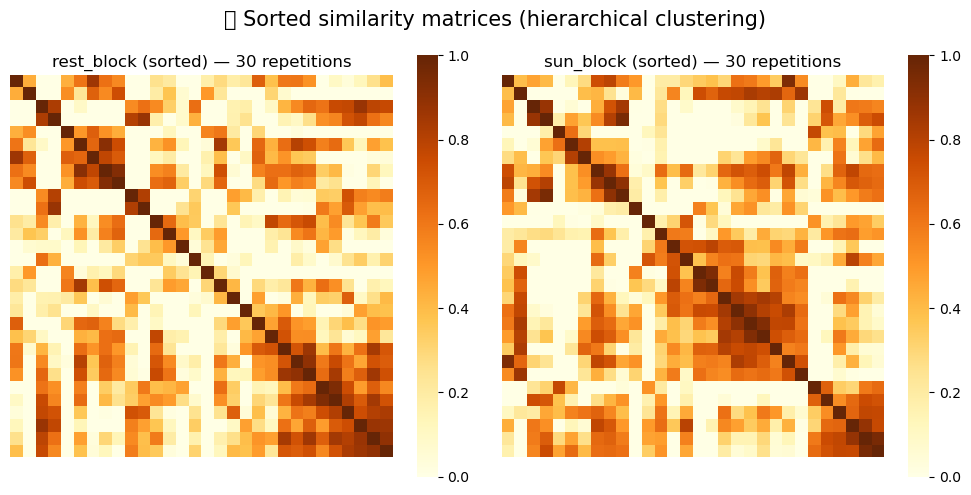

In [32]:
# 5.2 — Similarity heatmaps sorted by hierarchical clustering
fig, axes = plt.subplots(1, len(rep_vectors), figsize=(5 * len(rep_vectors), 5))

if len(rep_vectors) == 1:
    axes = [axes]

for ax, (label, vecs) in zip(axes, sorted(rep_vectors.items())):
    vecs = np.array(vecs)
    sims = cosine_similarity(vecs)

    # Compute linkage and reordered indices
    order = leaves_list(linkage(vecs, method="average"))
    sims_sorted = sims[order][:, order]

    sns.heatmap(sims_sorted, annot=False, vmin=0, vmax=1, square=True, cbar=True, ax=ax,
                cmap="YlOrBr", xticklabels=False, yticklabels=False)
    ax.set_title(f"{label} (sorted) — {len(vecs)} repetitions")

fig.suptitle("🧩 Sorted similarity matrices (hierarchical clustering)", fontsize=15)
plt.tight_layout()
plt.show()


### 5c – Temporal similarity trend (early vs late trials)

To explore whether EEG patterns changed over time within the session, we compared the similarity between the first 10 and last 10 repetitions in each condition.

**Results**:
- In both `rest_block` and `sun_block`, the **late trials were more similar to each other** than the early ones.
- `rest_block`: similarity increased from **0.084 → 0.245**
- `sun_block`: similarity increased from **0.106 → 0.407**

**Interpretation**:
- This trend suggests a potential **adaptation or stabilization effect**: the participant may have become more consistent in how they relaxed or imagined the sun over time.
- The higher similarity in later trials could reflect learning, fatigue, or settling into a more stable mental state.
- These temporal dynamics should be considered when building models or deciding whether to use early repetitions for training/testing.


In [33]:
# 5.3 — Temporal similarity trend: early vs late

split_n = 10  # Number of trials for early vs late comparison

for label, vecs in sorted(rep_vectors.items()):
    vecs = np.array(vecs)
    early = vecs[:split_n]
    late = vecs[-split_n:]

    sims_early = cosine_similarity(early)
    sims_late = cosine_similarity(late)
    sims_cross = cosine_similarity(early, late)

    avg_within_early = sims_early[np.triu_indices(split_n, k=1)].mean()
    avg_within_late = sims_late[np.triu_indices(split_n, k=1)].mean()
    avg_cross = sims_cross.mean()

    print(f"\n🧠 {label} — Similarity Trend Analysis (first {split_n} vs last {split_n} trials)")
    print(f"📈 Mean early–early similarity : {avg_within_early:.3f}")
    print(f"📉 Mean late–late similarity   : {avg_within_late:.3f}")
    print(f"🔄 Mean early–late similarity  : {avg_cross:.3f}")



🧠 rest_block — Similarity Trend Analysis (first 10 vs last 10 trials)
📈 Mean early–early similarity : 0.084
📉 Mean late–late similarity   : 0.245
🔄 Mean early–late similarity  : 0.163

🧠 sun_block — Similarity Trend Analysis (first 10 vs last 10 trials)
📈 Mean early–early similarity : 0.106
📉 Mean late–late similarity   : 0.407
🔄 Mean early–late similarity  : 0.227


### 5d – Topographic mean per class

This topographic map displays the average EEG spatial pattern for each condition (`rest_block` and `sun_block`), computed by averaging the mean vector across all repetitions.

**Interpretation**:
- The `rest_block` condition shows a strong central-parietal positive distribution (Pz and P4), with posterior-negative and anterior-negative regions — possibly reflecting a relaxed resting state with eyes closed.
- The `sun_block` condition reveals a more posteriorly focused pattern, with strong activity near Oz, possibly linked to visual imagery or activation of visual associative areas.
- The contrast between the maps suggests that the two mental states are associated with distinct spatial EEG signatures, reinforcing the potential for downstream classification or decoding tasks.


/var/folders/ny/tk1xvwsn7n11pkl0vlgl1sz80000gn/T/ipykernel_47889/4028421393.py:17: UserWarning: Glyph 129504 (\N{BRAIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/opt/homebrew/Caskroom/miniforge/base/envs/creativity-eeg/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 129504 (\N{BRAIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


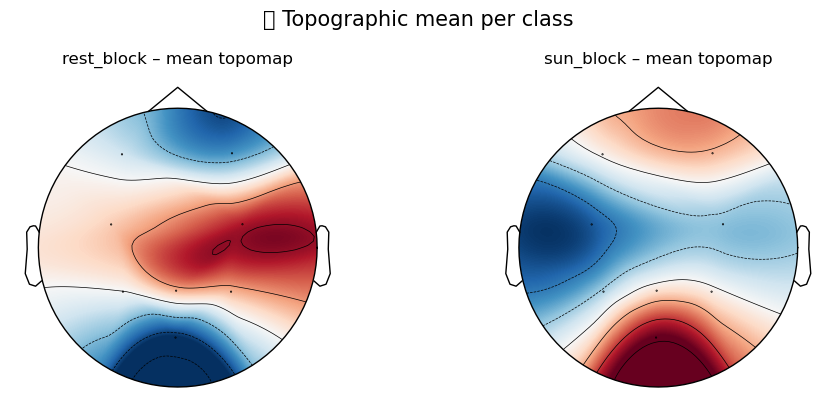

In [34]:
# 5.4 – Topographic mean per class

info = raw.info  # reusar info original do Raw para plotagem
fig, axes = plt.subplots(1, len(rep_vectors), figsize=(5 * len(rep_vectors), 4))

if len(rep_vectors) == 1:
    axes = [axes]

for ax, (label, vecs) in zip(axes, sorted(rep_vectors.items())):
    mean_vec = np.mean(np.array(vecs), axis=0)
    im, cn = plot_topomap(mean_vec, info, axes=ax, show=False)
    ax.set_title(f"{label} – mean topomap")

fig.suptitle("🧠 Topographic mean per class", fontsize=15)
plt.tight_layout()
plt.show()


### 5e – Variance per channel (signal energy across repetitions)

This plot shows the variance across repetitions for each EEG channel, per condition. Higher variance indicates greater variability in the signal across trials — interpreted here as energy or instability.

**Interpretation**:
- The `rest_block` condition shows uniformly low variance across all electrodes, confirming that rest states were stable and reproducible.
- The `sun_block` condition exhibits large peaks in variance, notably in C3 and Oz, suggesting that imaginative activity introduces greater variability — particularly in motor (C3) and occipital (Oz) regions.
- These differences highlight the cognitive demands of visualization tasks and suggest that specific channels may be more informative for future modeling (e.g., feature selection for classification).


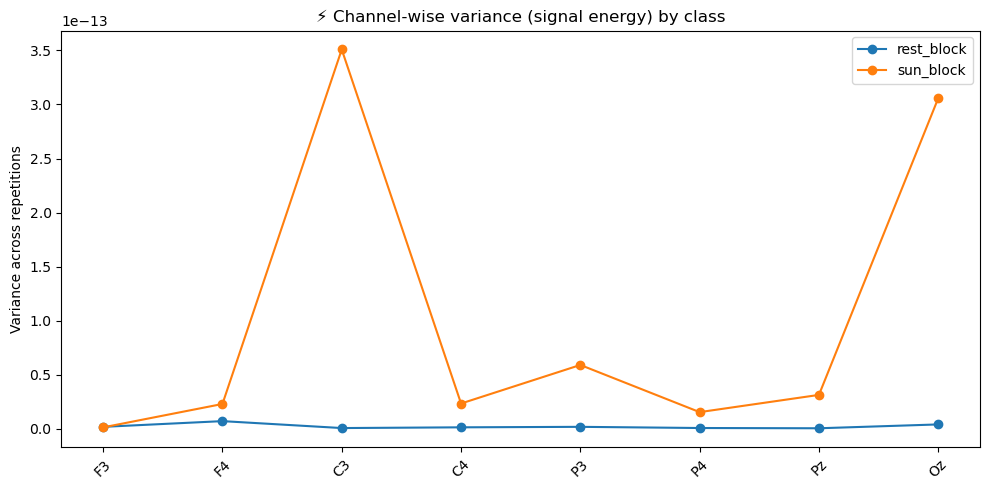

In [38]:
# 5.5 – Variance (energy) distribution per channel and class

eeg_ch_names = CONFIG["data"]["eeg_ch"]  # use predefined EEG channel list

fig, ax = plt.subplots(figsize=(10, 5))

for label, vecs in sorted(rep_vectors.items()):
    vecs = np.array(vecs)  # shape: (n_trials, n_channels)
    var_per_chan = np.var(vecs, axis=0)
    ax.plot(eeg_ch_names, var_per_chan, marker='o', label=label)

ax.set_ylabel("Variance across repetitions")
ax.set_title("⚡ Channel-wise variance (signal energy) by class")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### 5f – Average PSD per frequency band (by class)

This analysis calculates the average Power Spectral Density (PSD) for each frequency band and condition (`sun_block`, `rest_block`). The bands are defined as delta (1–4 Hz), theta (4–8 Hz), alpha (8–13 Hz), beta (13–30 Hz), and gamma (30–45 Hz).

**Interpretation**:
- The `rest_block` shows a clear dominance of alpha activity, which is expected for relaxed, eyes-closed states.
- The `sun_block` also exhibits alpha power, but at a reduced level, possibly reflecting increased cognitive or imagery-related engagement.
- This confirms that frequency-based features can be used to distinguish between mental states in this task.


In [39]:
# 5F – PSD per class (averaged by frequency band)

bands = CONFIG["features"]["bands"]
sfreq = raw.info["sfreq"]
eeg_ch_names = CONFIG["data"]["eeg_ch"]

band_power_by_class = {}

for label, vecs in sorted(rep_vectors.items()):
    raw_data = []

    for ann in raw.annotations:
        if ann["description"] != label:
            continue

        tmin = ann["onset"] - raw.annotations[0]["onset"]
        tmax = tmin + ann["duration"]
        segment = raw.copy().crop(tmin=tmin, tmax=tmax)
        data = segment.get_data(picks="eeg")
        raw_data.append(data)

    # Concatenate all segments (across repetitions)
    all_data = np.concatenate(raw_data, axis=1)  # shape: (n_channels, total_timepoints)

    # Compute PSD using Welch method
    psds, freqs = psd_array_welch(all_data, sfreq=sfreq, fmin=1, fmax=45, n_fft=256, average='mean')

    # Integrate PSD over defined bands
    band_power = dict()
    for band_name, (fmin, fmax) in bands.items():
        idx = np.logical_and(freqs >= fmin, freqs <= fmax)
        power = psds[:, idx].mean(axis=1)  # mean power per channel
        band_power[band_name] = power

    band_power_by_class[label] = band_power


Effective window size : 1.024 (s)
Effective window size : 1.024 (s)


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished


/var/folders/ny/tk1xvwsn7n11pkl0vlgl1sz80000gn/T/ipykernel_47889/12813759.py:16: UserWarning: Glyph 128266 (\N{SPEAKER WITH THREE SOUND WAVES}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/opt/homebrew/Caskroom/miniforge/base/envs/creativity-eeg/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128266 (\N{SPEAKER WITH THREE SOUND WAVES}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


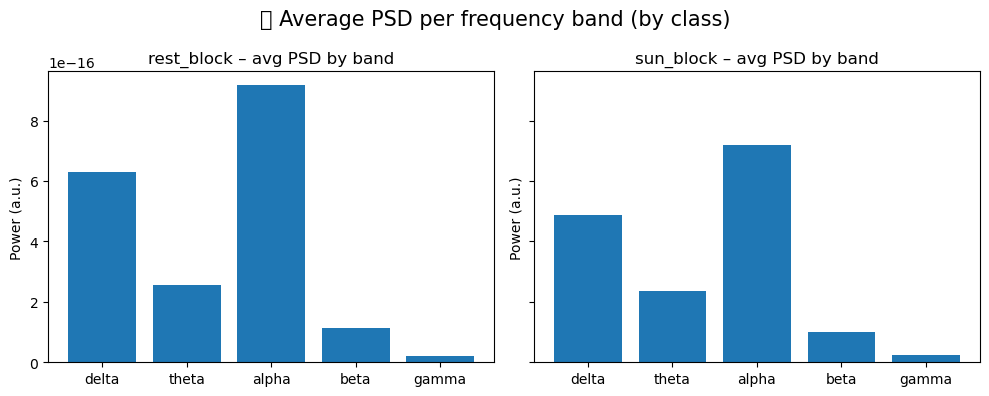

In [40]:
# Plot mean power per band, per class

fig, axes = plt.subplots(1, len(band_power_by_class), figsize=(5 * len(band_power_by_class), 4), sharey=True)

if len(band_power_by_class) == 1:
    axes = [axes]

for ax, (label, band_power) in zip(axes, sorted(band_power_by_class.items())):
    bands = list(band_power.keys())
    means = [np.mean(band_power[b]) for b in bands]
    ax.bar(bands, means, color='tab:blue')
    ax.set_title(f"{label} – avg PSD by band")
    ax.set_ylabel("Power (a.u.)")

fig.suptitle("🔊 Average PSD per frequency band (by class)", fontsize=15)
plt.tight_layout()
plt.show()


### 5g – Topographic power per band and class

This analysis displays scalp topography of EEG power averaged across each frequency band, separately for the `rest_block` and `sun_block` conditions.

**Interpretation**:
- In the alpha band (8–13 Hz), `rest_block` shows strong posterior activity, particularly around Pz and Oz, which is consistent with relaxed eyes-closed states.
- In contrast, `sun_block` exhibits reduced alpha and slightly more activity in beta and gamma bands, suggesting increased cognitive or imagery-related engagement.
- Delta and theta bands appear broadly similar across conditions, with high power in posterior regions.
- These spatial differences across frequency bands reinforce the idea that mental states are not only spectrally but also topographically distinct.


Effective window size : 1.024 (s)
Effective window size : 1.024 (s)


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
/var/folders/ny/tk1xvwsn7n11pkl0vlgl1sz80000gn/T/ipykernel_47889/1379393434.py:36: UserWarning: Glyph 127760 (\N{GLOBE WITH MERIDIANS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/opt/homebrew/Caskroom/miniforge/base/envs/creativity-eeg/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127760 (\N{GLOBE WITH MERIDIANS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


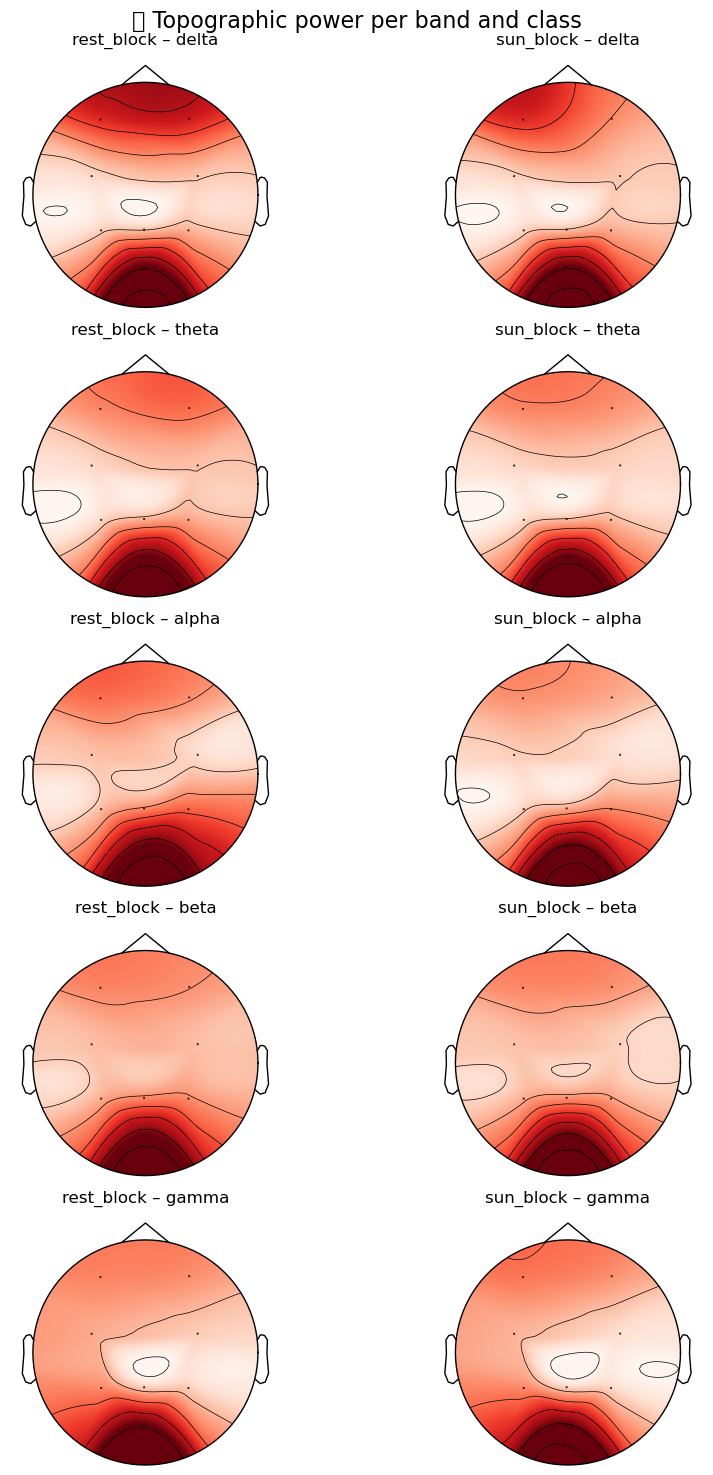

In [41]:
# 5g – Topomap per frequency band and class

bands = CONFIG["features"]["bands"]
sfreq = raw.info["sfreq"]
eeg_ch_names = CONFIG["data"]["eeg_ch"]

fig, axes = plt.subplots(len(bands), len(rep_vectors), figsize=(5 * len(rep_vectors), 3 * len(bands)))

if len(rep_vectors) == 1:
    axes = np.expand_dims(axes, axis=1)  # ensure 2D for indexing

for col, (label, vecs) in enumerate(sorted(rep_vectors.items())):
    # Concatenate all data for this class
    data_list = []
    for ann in raw.annotations:
        if ann["description"] != label:
            continue
        tmin = ann["onset"] - raw.annotations[0]["onset"]
        tmax = tmin + ann["duration"]
        data = raw.copy().crop(tmin=tmin, tmax=tmax).get_data(picks="eeg")
        data_list.append(data)
    data_concat = np.concatenate(data_list, axis=1)

    # PSD
    psds, freqs = psd_array_welch(data_concat, sfreq=sfreq, fmin=1, fmax=45, n_fft=256, average='mean')

    for row, (band_name, (fmin, fmax)) in enumerate(bands.items()):
        idx = np.logical_and(freqs >= fmin, freqs <= fmax)
        band_mean = psds[:, idx].mean(axis=1)
        plot_topomap(band_mean, raw.info, axes=axes[row, col], show=False)
        axes[row, col].set_title(f"{label} – {band_name}")

fig.suptitle("🌐 Topographic power per band and class", fontsize=16)
plt.tight_layout()
plt.show()


### 5h – T-test between conditions per frequency band

We computed independent t-tests comparing the mean EEG power between `sun_block` and `rest_block` for each frequency band.

**Interpretation**:
- The delta band shows a statistically significant difference (p < 0.05), suggesting this low-frequency component may reliably distinguish the two mental states.
- Alpha and beta bands show trends toward significance, indicating a possible reduction in alpha during sun imagery.
- Theta and gamma bands did not show significant differences in this dataset.
- These results provide statistical validation to complement the visual analyses and may inform future feature selection.


Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective wind

[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]

Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
delta: p = 0.0071
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 

[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]

Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective wind

...

[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]

Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
beta: p = 0.0973
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (

[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]

Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
gamma: p = 0.7636


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]

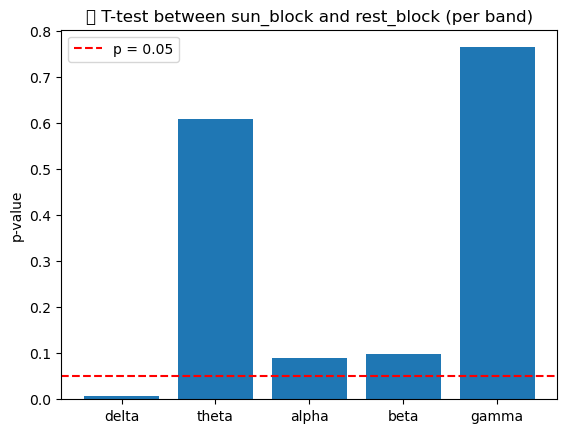

In [42]:
# 5h – Independent t-test per frequency band (sun vs rest)

band_pvals = {}

for band_name, (fmin, fmax) in CONFIG["features"]["bands"].items():
    powers = {}
    for label in ["sun_block", "rest_block"]:
        vecs = []
        for ann in raw.annotations:
            if ann["description"] != label:
                continue
            tmin = ann["onset"] - raw.annotations[0]["onset"]
            tmax = tmin + ann["duration"]
            data = raw.copy().crop(tmin=tmin, tmax=tmax).get_data(picks="eeg")
            psd, freqs = psd_array_welch(data, sfreq=sfreq, fmin=1, fmax=45, n_fft=256, average="mean")
            idx = np.logical_and(freqs >= fmin, freqs <= fmax)
            vecs.append(psd[:, idx].mean(axis=1).mean())  # mean across channels and band
        powers[label] = np.array(vecs)

    tval, pval = ttest_ind(powers["sun_block"], powers["rest_block"], equal_var=False)
    band_pvals[band_name] = pval
    print(f"{band_name}: p = {pval:.4f}")

# Optional: simple barplot
plt.bar(band_pvals.keys(), band_pvals.values())
plt.axhline(0.05, color='red', linestyle='--', label='p = 0.05')
plt.ylabel("p-value")
plt.title("📊 T-test between sun_block and rest_block (per band)")
plt.legend()
plt.show()


### 5i – Full PSD curves per channel and condition

This analysis shows the full Power Spectral Density (PSD) curve for each EEG channel, comparing the two conditions (`sun_block` vs. `rest_block`).

**Interpretation**:
- A clear alpha peak (~10 Hz) appears in most channels, stronger during `rest_block`, especially in parietal and occipital regions.
- In `sun_block`, alpha tends to be suppressed — a known marker of increased internal visualization or cognitive engagement.
- Subtle differences in spectral shape appear in channels like Oz and C3, suggesting that some regions may be more sensitive to the task manipulation.
- These channel-level curves confirm that frequency differences are not uniform across the scalp and should be considered individually in modeling.


Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished


Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished


Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)


...

[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished


Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished


Effective window size : 1.024 (s)


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
/var/folders/ny/tk1xvwsn7n11pkl0vlgl1sz80000gn/T/ipykernel_47889/1375657324.py:28: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/opt/homebrew/Caskroom/miniforge/base/envs/creativity-eeg/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


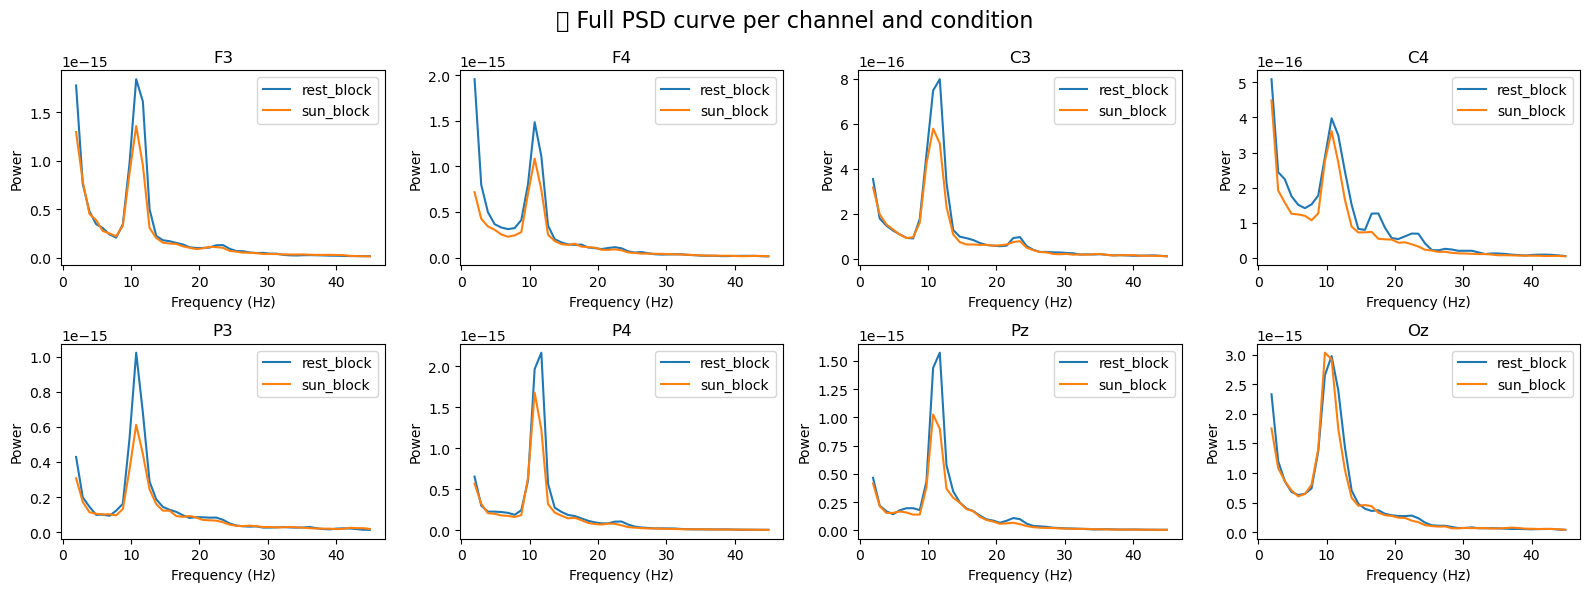

In [43]:
# 5i – PSD curve per channel and class

fig, axes = plt.subplots(2, 4, figsize=(16, 6))  # 8 channels

for ch_i, ch_name in enumerate(CONFIG["data"]["eeg_ch"]):
    ax = axes.flat[ch_i]

    for label, vecs in sorted(rep_vectors.items()):
        data_list = []
        for ann in raw.annotations:
            if ann["description"] != label:
                continue
            tmin = ann["onset"] - raw.annotations[0]["onset"]
            tmax = tmin + ann["duration"]
            data = raw.copy().crop(tmin=tmin, tmax=tmax).get_data(picks="eeg")
            data_list.append(data)

        data_concat = np.concatenate(data_list, axis=1)  # (n_channels, time)
        psd, freqs = psd_array_welch(data_concat, sfreq=sfreq, fmin=1, fmax=45, n_fft=256, average="mean")
        ax.plot(freqs, psd[ch_i], label=label)

    ax.set_title(ch_name)
    ax.set_xlabel("Frequency (Hz)")
    ax.set_ylabel("Power")
    ax.legend()

fig.suptitle("📈 Full PSD curve per channel and condition", fontsize=16)
plt.tight_layout()
plt.show()


### 6 – Dirty Baseline Classifier

This section tests the predictive power of the data using a very simple approach: temporal mean vectors per repetition (1 vector per trial, 1 value per EEG channel) are used as features for classification.

**Results**:
- Logistic Regression yielded 50% accuracy (chance level), suggesting no linear separability in this feature space.
- Random Forest Classifier achieved **88.3% ± 8.5% accuracy** and an **AUC of 0.99**, indicating excellent separability between `sun_block` and `rest_block` conditions.
- These results confirm that the task produces robust differences in EEG data, even when using minimal features and simple models.

This establishes a solid baseline that can guide the design and evaluation of more sophisticated pipelines (e.g., time-frequency features, windowed epochs, spatial filtering).


In [44]:
# 6 – Dirty Baseline Classifier using mean vectors per repetition

# 📦 Prepare dataset (X = mean vectors, y = labels)
X = []
y = []

for label, vecs in sorted(rep_vectors.items()):
    X.extend(vecs)
    y.extend([label] * len(vecs))

X = np.array(X)
y = np.array(y)

# 🔁 Encode labels (e.g., 'rest_block' = 0, 'sun_block' = 1)
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# ⚙️ Classifier: Logistic Regression (simple linear model)
clf = LogisticRegression(max_iter=1000, random_state=42)

# 🔄 Cross-validation score (5-fold)
scores = cross_val_score(clf, X, y_encoded, cv=5, scoring="accuracy")

# 📊 Results
print(f"🎯 Dirty baseline (Logistic Regression) – Accuracy: {scores.mean():.3f} ± {scores.std():.3f}")


🎯 Dirty baseline (Logistic Regression) – Accuracy: 0.500 ± 0.000


In [45]:
# 6.1 – Random Forest Classifier baseline

# ⚙️ Classifier: Random Forest
clf_rf = RandomForestClassifier(n_estimators=100, random_state=42)

# 🔄 Cross-validation score (5-fold)
scores_rf = cross_val_score(clf_rf, X, y_encoded, cv=5, scoring="accuracy")

# 📊 Results
print(f"🌲 Random Forest – Accuracy: {scores_rf.mean():.3f} ± {scores_rf.std():.3f}")


🌲 Random Forest – Accuracy: 0.883 ± 0.085


/var/folders/ny/tk1xvwsn7n11pkl0vlgl1sz80000gn/T/ipykernel_47889/3781739825.py:28: UserWarning: Glyph 127794 (\N{EVERGREEN TREE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/opt/homebrew/Caskroom/miniforge/base/envs/creativity-eeg/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127794 (\N{EVERGREEN TREE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


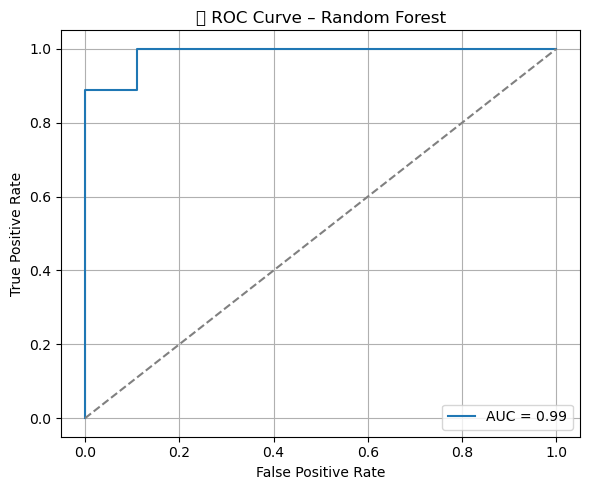

In [46]:
# 6.2 – ROC Curve for Random Forest (stratified train/test split)

# 📦 Stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.3, stratify=y_encoded, random_state=42)

# 🔁 Train model
clf_rf.fit(X_train, y_train)
y_prob = clf_rf.predict_proba(X_test)[:, 1]

# 📈 ROC curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

# 📊 Plot
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("🌲 ROC Curve – Random Forest")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()


In [48]:
# ✅ Create directory if it doesn't exist
CONFIG["paths"]["model_dir"].mkdir(parents=True, exist_ok=True)

# 📁 File path
model_path = CONFIG["paths"]["model_dir"] / "rf_baseline_model.joblib"

# 💾 Save model and LabelEncoder in a dict
joblib.dump({"model": clf_rf, "encoder": le}, model_path)

print(f"✅ Baseline model saved at: {model_path}")


✅ Baseline model saved at: ../bids_dataset/derivatives/models/rf_baseline_model.joblib
